In [1]:
# Import Packages & Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read in csv, save to dataframe (df)
df = pd.read_csv('medical_time_series.csv')

# Visually inspect dataframe at a high level to spot any apparent issues
pd.set_option("display.max_columns", None)
df

,Day,Revenue
0,1,0.000000
1,2,-0.292356
2,3,-0.327772
3,4,-0.339987
4,5,-0.124888
...,...,...
726,727,15.722056
727,728,15.865822
728,729,15.708988
729,730,15.822867


In [3]:
# Check data types, number of values and size
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.5 KB


# Part III: Data Preparation

## C4. Data Preparation Steps

### Step 1. Convert 'Day' to 'Date' (DateTime object)
The course provided time series dataset records daily revenue, in million dollars (which will be assumed to be USD), during the first two years of operation. Unfortunately, our data dictionary neglects to mention what years this data is taken from, however, it does include the presence of 731 daily observations, indicating the dataset includes data from a leap year (since there are 365 days in a year, a normal 2-year span would mean there would be only 730 observations). Assuming this would be relatively recent information and the last known leap year occurred in 2020, we’ll provide a start date of 01/01/2020 for this information.  

In [4]:
# Create a new datetime object, representing a start date of 01/01/2020 (the most recent 2-year range that includes a leap year)
start_date = pd.to_datetime('2020-01-01')

# Convert 'Day' column to actual dates
df['Day'] = pd.to_timedelta(df['Day']-1, unit='D') + start_date

# Rename columns
df.columns = ['date', 'revenue']

# Set 'date' as the index, so our dataset wiill be treated as chronological data
df.set_index('date', inplace=True)

# Visually inspect final dataframe to verify appearance as expected
df

,revenue
date,
2020-01-01,0.000000
2020-01-02,-0.292356
2020-01-03,-0.327772
2020-01-04,-0.339987
2020-01-05,-0.124888
...,...
2021-12-27,15.722056
2021-12-28,15.865822
2021-12-29,15.708988


## C1. Line Graph Visualizing the Realization of the Time Series

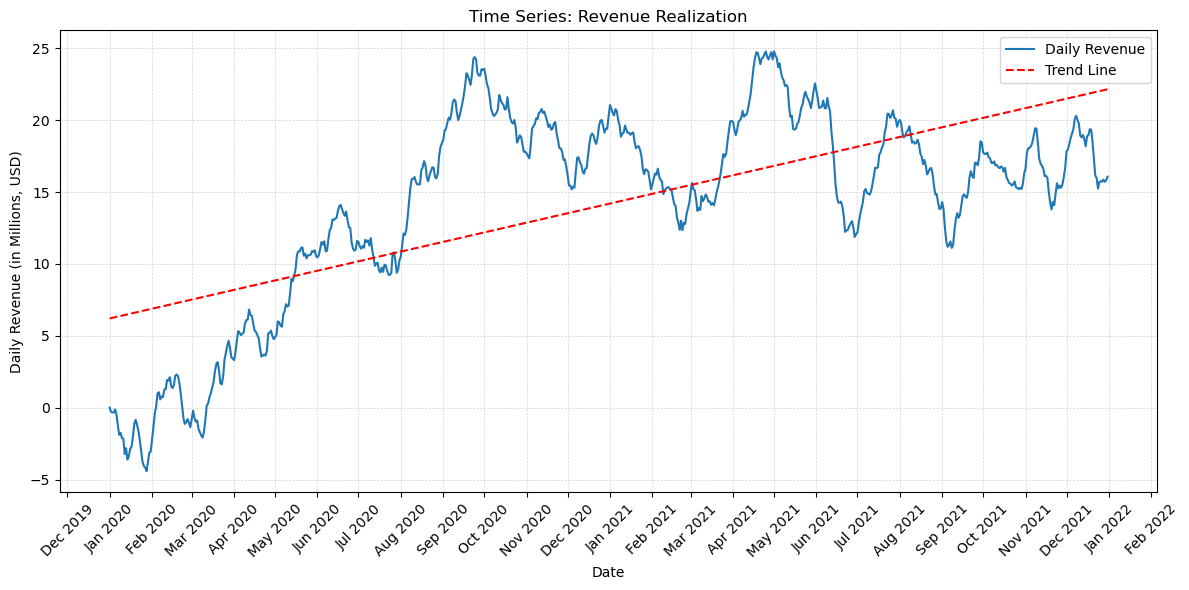

In [5]:
# Plotting the time series line graph
plt.figure(figsize=(12, 6))
plt.title("Time Series: Revenue Realization")
plt.xlabel("Date")
plt.ylabel("Daily Revenue (in Millions, USD)")
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5)

# Plot the revenue line
plt.plot(df.index, df['revenue'], label='Daily Revenue')

# Add trend line
x = mdates.date2num(df.index.to_pydatetime())
y = df['revenue'].values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(df.index, p(x), "r--", label='Trend Line')

# Make x-axis look nicer
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## C3. Stationarity of the Time Series

In [6]:
# Perform Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(df)

# ADF test components 
adf_stat = adf_result[0] # test stat
p_value = adf_result[1] # p-value
critical_values = adf_result[4] # crit values

# Display ADF test results
print("Augmented Dickey-Fuller Test Results:\n -----------------------------------")
print(f"• ADF Statistic: {adf_stat:.4f}")
print(f"• p-value: {p_value:.4f}")
print("• Critical Values:")
for key, value in critical_values.items():
    print(f"  • {key} level: {value:.4f}")
print("-----------------------------------")

Augmented Dickey-Fuller Test Results:
 -----------------------------------
• ADF Statistic: -2.2183
• p-value: 0.1997
• Critical Values:
  • 1% level: -3.4394
  • 5% level: -2.8655
  • 10% level: -2.5689
-----------------------------------


The test statistic of an augmented Dicky-Fuller test on this data is -17.3748, which has a p-value of 0.0


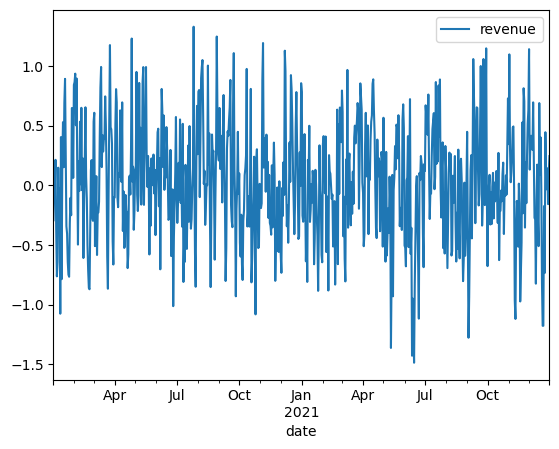

In [7]:
df_transformed = df.diff().dropna()

# Perform Augmented Dicky-Fuller on data
adfuller_results = adfuller(df_transformed.revenue)

# Print resulting test-statistic and p-value
print(f"The test statistic of an augmented Dicky-Fuller test on this data is {round(adfuller_results[0], 4)}, which has a p-value of {round(adfuller_results[1], 8)}")

# Plot to verify stationarity
df_transformed.plot();

## C4. Data Preparation Steps (Cont.)

### Step 2. Check for Missing Values 

In [8]:
# Check for missing values in our dataset
df.isnull().sum()

revenue    0
dtype: int64

### Step 3. Check for Outliers

In [9]:
# Summary statistics for revenue
df.describe()

,revenue
count,731.000000
mean,14.179608
std,6.959905
min,-4.423299
25%,11.121742
50%,15.951830
75%,19.293506
max,24.792249


In [10]:
# Check for outliers in our revenue
revenue_largest = df['revenue'].nlargest(10)
revenue_smallest = df['revenue'].nsmallest(10)

print("LOWEST DAILY REVENUES BY DATE (Low to High):\n", revenue_smallest.to_string(index=True))
print("\nHIGHEST DAILY REVENUES BY DATE (High to Low):\n", revenue_largest.to_string(index=True))

LOWEST DAILY REVENUES BY DATE (Low to High):
 date
2020-01-28   -4.423299
2020-01-27   -4.172912
2020-01-26   -4.068318
2020-01-29   -3.773237
2020-01-25   -3.749676
2020-01-14   -3.609713
2020-01-15   -3.398875
2020-01-12   -3.228637
2020-01-30   -3.130366
2020-01-31   -3.066997

HIGHEST DAILY REVENUES BY DATE (High to Low):
 date
2021-05-01    24.792249
2021-04-25    24.786487
2021-04-29    24.737544
2021-04-18    24.719916
2021-04-19    24.702191
2021-04-24    24.592677
2021-04-28    24.504853
2021-05-02    24.502237
2021-04-26    24.401791
2020-09-24    24.390297


### Step 4. Split the dataset into training & test sets

In [11]:
# Set proportion (80% train, 20% test)
split_point = int(len(df) * 0.8)

# Split into training and test sets
train = df.iloc[:split_point]
test = df.iloc[split_point:]

## C5. Cleaned Dataset

In [12]:
# Save training and test sets to CSV
train.to_csv('d213_task1_train.csv')
test.to_csv('d213_task1_test.csv')

# Part IV: Model Identification & Analysis

## D1. Annotated Findings & Visualizations

### 1. Seasonality

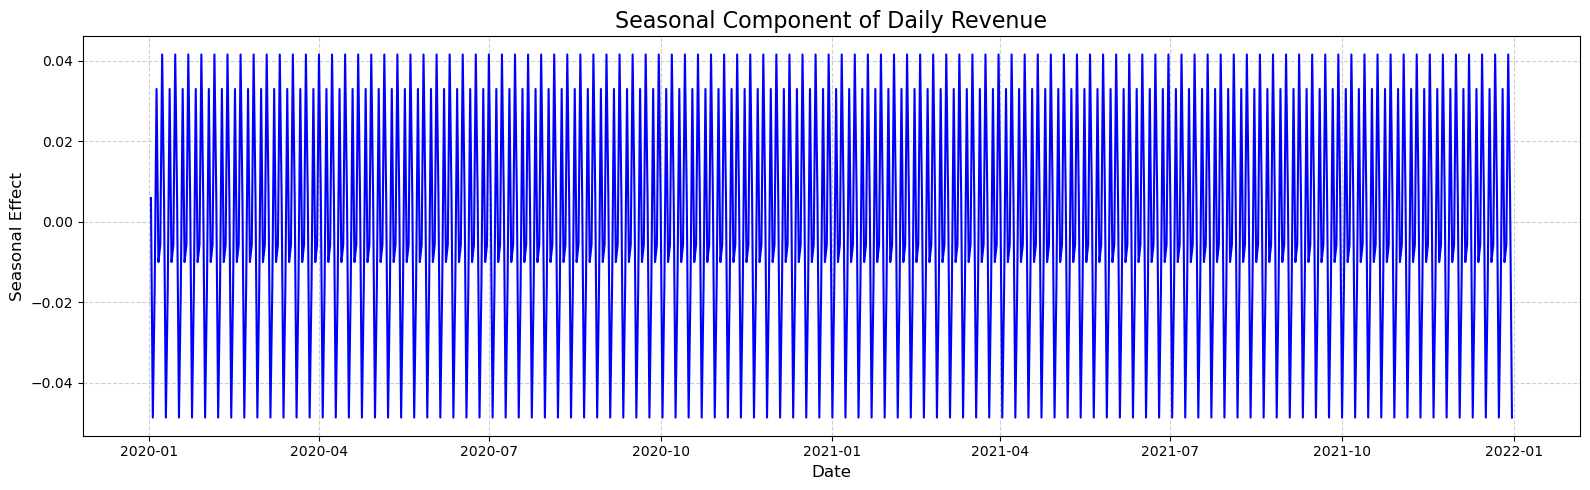

In [13]:
# Perform seasonal decomposition
decomp = seasonal_decompose(df_transformed)

# Plot the seasonal component
plt.figure(figsize = [16,5])
plt.plot(decomp.seasonal, color='blue')
plt.title("Seasonal Component of Daily Revenue", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Seasonal Effect", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

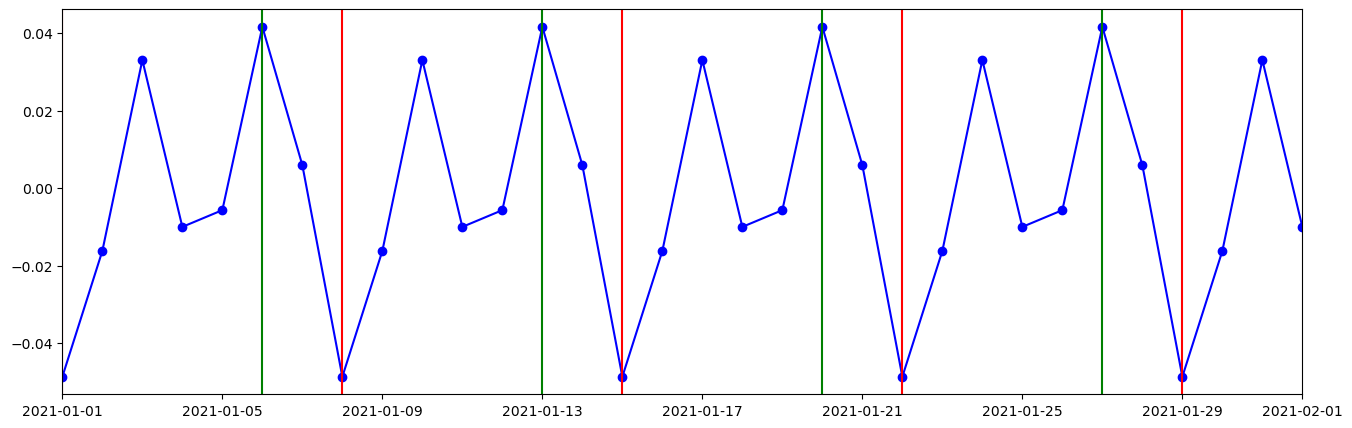

In [14]:
# Plot the seasonal component
plt.figure(figsize = [16,5])
plt.plot(decomp.seasonal, marker='o', color='blue')
plt.xlim(pd.to_datetime('2021-01-01'), pd.to_datetime('2021-02-01'))

# Draw red lines on Fridays (lowest peaks)
plt.axvline(x=pd.to_datetime('2021-01-01'), color='red')
plt.axvline(x=pd.to_datetime('2021-01-08'), color='red')
plt.axvline(x=pd.to_datetime('2021-01-15'), color='red')
plt.axvline(x=pd.to_datetime('2021-01-22'), color='red')
plt.axvline(x=pd.to_datetime('2021-01-29'), color='red')

# Draw green lines on Wednesdays (highest peaks)
plt.axvline(x=pd.to_datetime('2021-01-06'), color='green')
plt.axvline(x=pd.to_datetime('2021-01-13'), color='green')
plt.axvline(x=pd.to_datetime('2021-01-20'), color='green')
plt.axvline(x=pd.to_datetime('2021-01-27'), color='green')

### 2. Trends

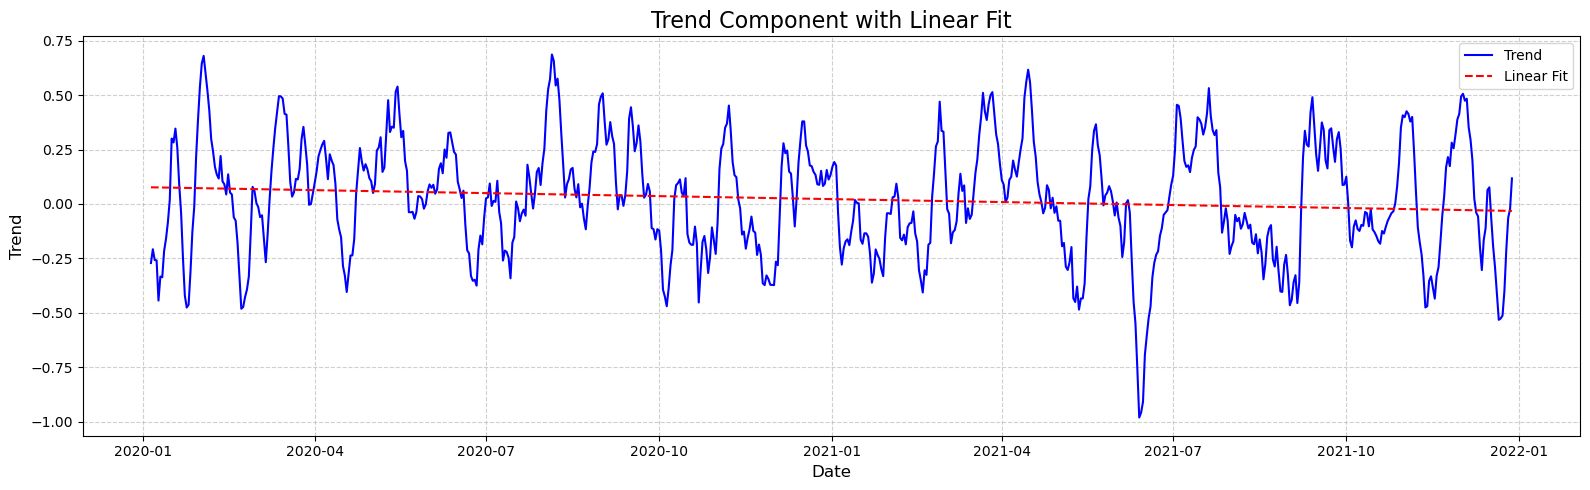

In [15]:
# Drop NaNs 
trend_clean = decomp.trend.dropna()
x_vals = mdates.date2num(trend_clean.index)
y_vals = trend_clean.values

# Fit a linear regression line
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)

# Plot trend with regression line
plt.figure(figsize=(16,5))
plt.plot(trend_clean.index, trend_clean, label='Trend', color='blue')
plt.plot(trend_clean.index, p(x_vals), 'r--', label='Linear Fit')
plt.title("Trend Component with Linear Fit", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Trend", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Autocorrelation Function (ACF)

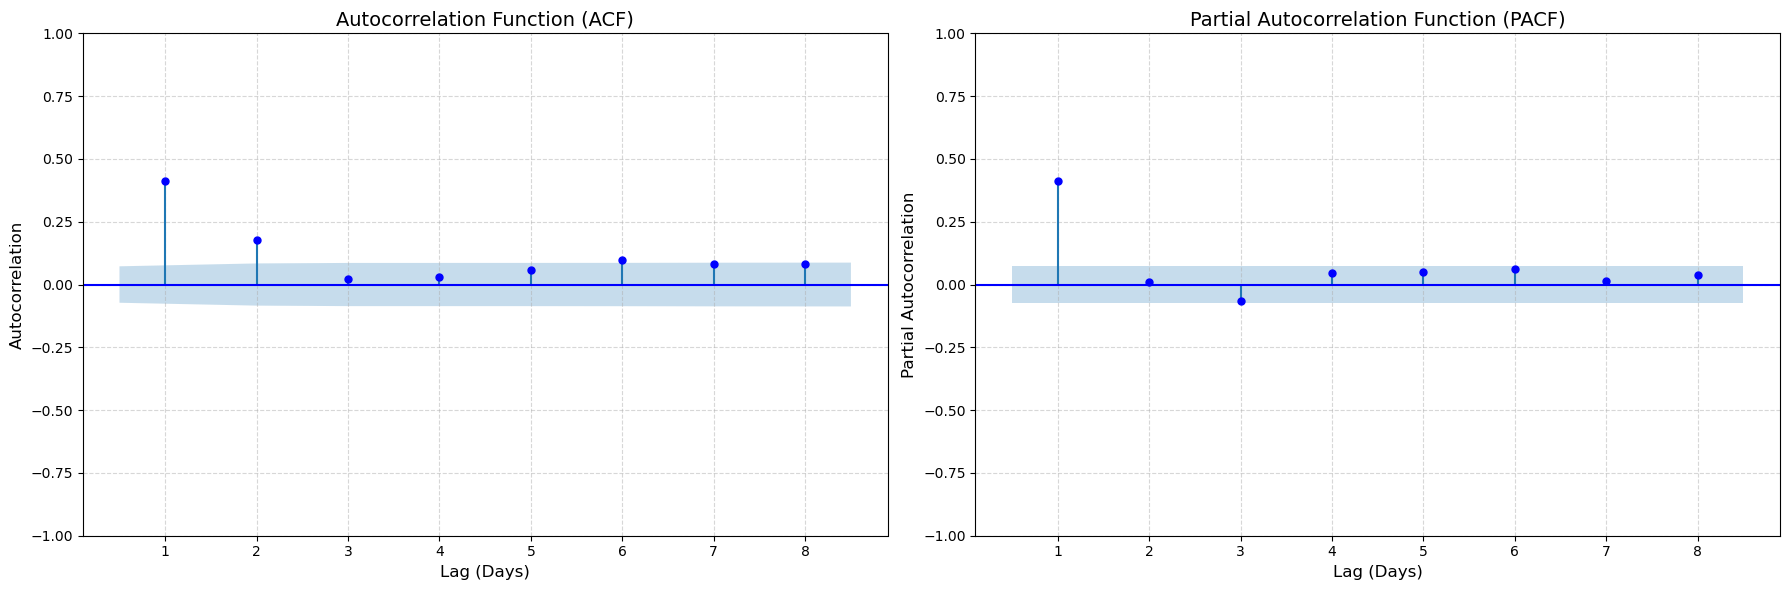

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# ACF plot
plot_acf(df_transformed, lags=8, ax=ax[0], color='blue', zero=False)
ax[0].set_title("Autocorrelation Function (ACF)", fontsize=14)
ax[0].set_xlabel("Lag (Days)", fontsize=12)
ax[0].set_ylabel("Autocorrelation", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.5)

# PACF plot
plot_pacf(df_transformed, lags=8, ax=ax[1], method='ywm', color='blue', zero=False)
ax[1].set_title("Partial Autocorrelation Function (PACF)", fontsize=14)
ax[1].set_xlabel("Lag (Days)", fontsize=12)
ax[1].set_ylabel("Partial Autocorrelation", fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4. Spectral Density

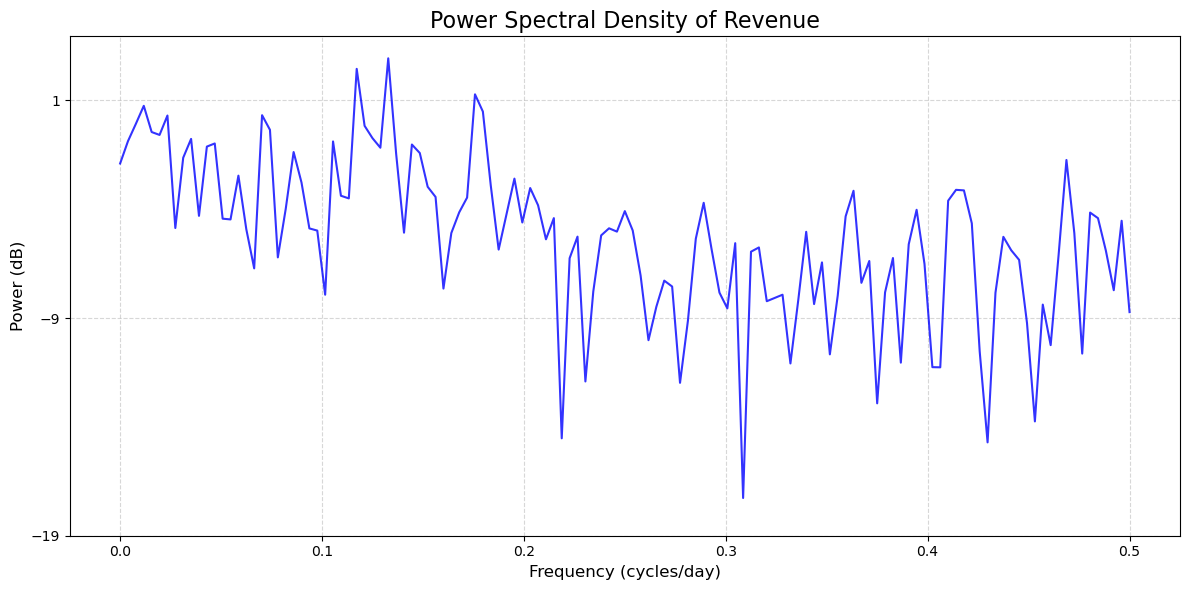

In [17]:
# Plot the spectral density
plt.figure(figsize=(12, 6))
plt.psd(df_transformed['revenue'], NFFT=256, Fs=1, color='blue', linewidth=1.5, alpha=0.8)
plt.title('Power Spectral Density of Revenue', fontsize=16)
plt.xlabel('Frequency (cycles/day)', fontsize=12)
plt.ylabel('Power (dB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5. Decomposed Time Series 

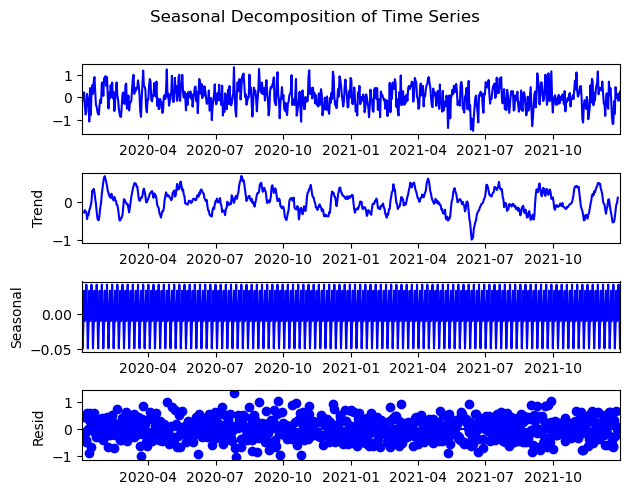

In [18]:
# Decomposed Time Series (Trend, Seasonality, Residual)decomposition = seasonal_decompose(df, model='additive', period=365)
fig = decomp.plot()

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color("blue")

plt.suptitle("Seasonal Decomposition of Time Series", y=1.02)
plt.tight_layout()
plt.show()

### 6. Residuals of Decomposition

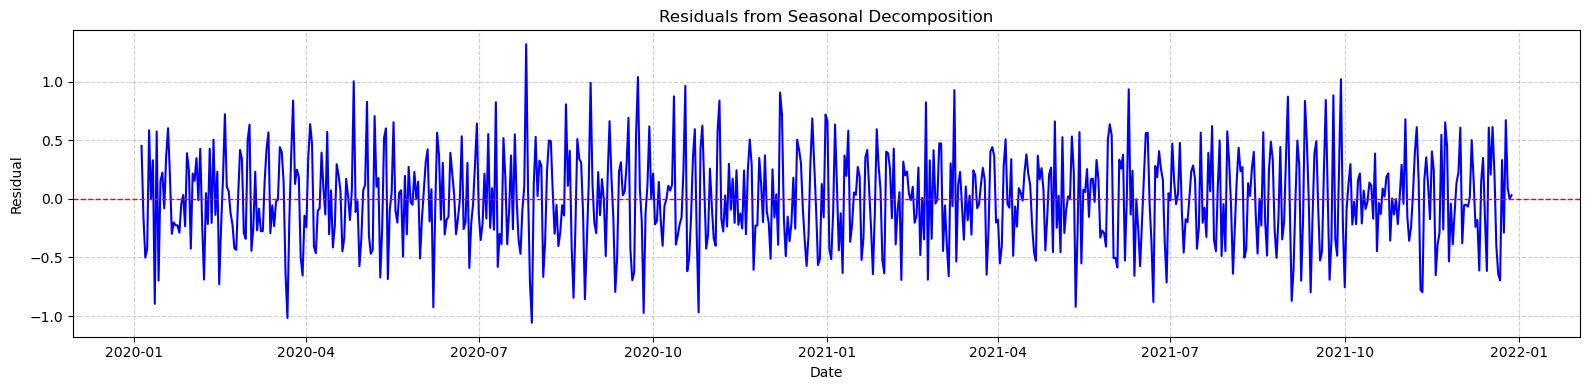

In [19]:
# Residuals of Decomposition - check for trends
plt.figure(figsize=(16, 4))
plt.plot(decomp.resid, color='blue', label='Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals from Seasonal Decomposition")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## D2. ARIMA Model

In [20]:
# Initialize model with monthly seasonality 
model = SARIMAX(train['revenue'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 30),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

model_results = model.fit(disp=False)

print(model_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            revenue   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 30)   Log Likelihood                -352.199
Date:                            Fri, 11 Apr 2025   AIC                            714.399
Time:                                    16:43:43   BIC                            735.677
Sample:                                01-01-2020   HQIC                           722.734
                                     - 08-06-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4421      0.106      4.163      0.000       0.234       0.650
ma.L1         -0.0506      0.121   

## D3. Forecast 

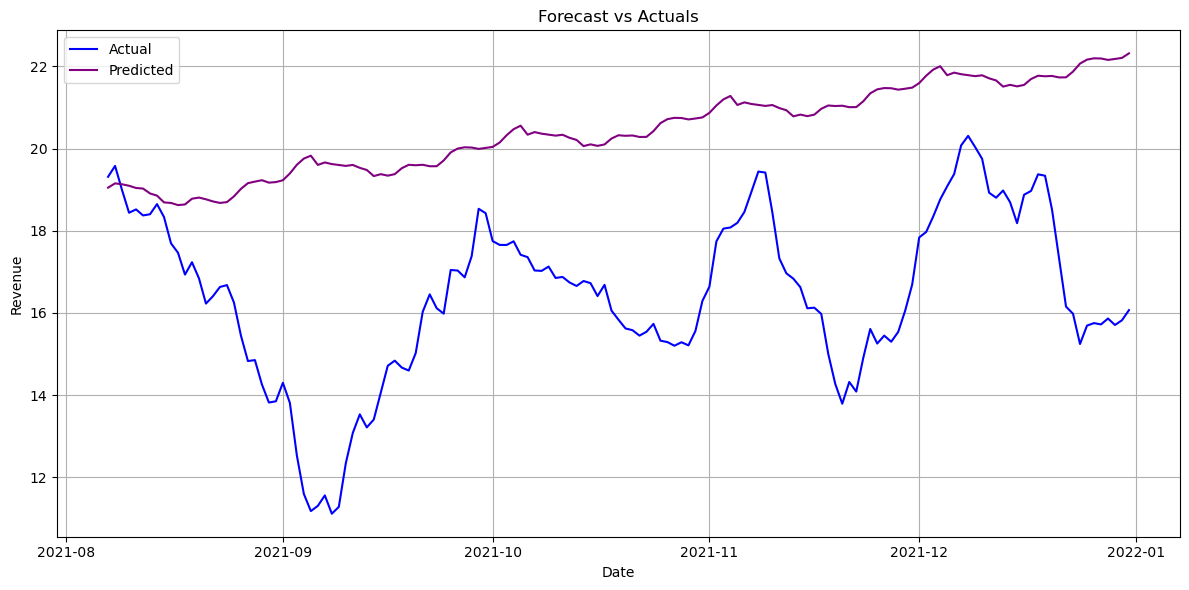

In [21]:
# Forecast for the test set period
forecast = model_results.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(pred_mean.index, pred_mean, label='Predicted', color='purple')
plt.title('Forecast vs Actuals')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Prepare dataframe for comparison
forecast_df = pd.DataFrame({
    'actual': test['revenue'],
    'forecast': pred_mean,
})


# Concatenate training data with forecast
combined_df = pd.concat([train.copy(), forecast_df.copy()])

# Extract NumPy arrays for plotting
x = forecast_df.index.values
y_actual = forecast_df['actual'].values
y_forecast = forecast_df['forecast'].values
y_lower = conf_int.iloc[:, 0].astype(float).values
y_upper = conf_int.iloc[:, 1].astype(float).values

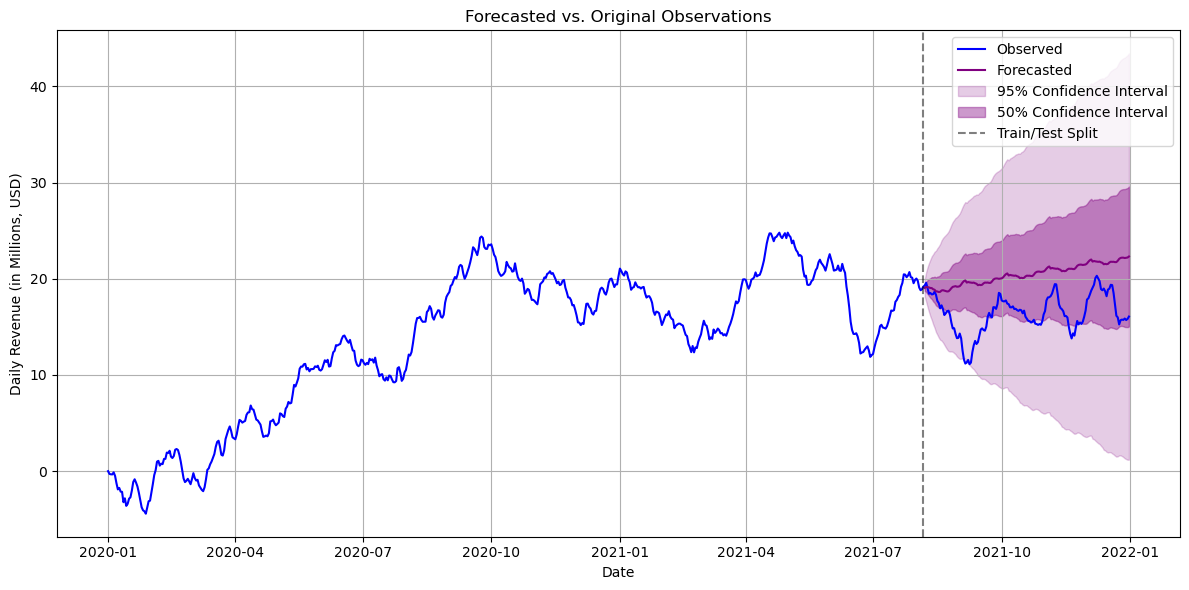

In [27]:
# Calculate 50% confidence interval 
conf_int_50 = forecast.conf_int(alpha=0.5)
conf_int_50.index = forecast_df.index

# Extract 50% interval bounds
y_lower_50 = conf_int_50.iloc[:, 0].astype(float).values
y_upper_50 = conf_int_50.iloc[:, 1].astype(float).values

# Plot forecast vs. actuals
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['revenue'], label='Observed', color='blue')
plt.plot(forecast_df.index,
         forecast_df['forecast'],
         label='Forecasted', color='purple')
plt.fill_between(x, y_lower, y_upper,
                 color='purple', alpha=0.2, label='95% Confidence Interval')
plt.fill_between(x, y_lower_50, y_upper_50,
                 color='purple', alpha=0.4, label='50% Confidence Interval')
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5, label='Train/Test Split')
plt.title('Forecasted vs. Original Observations')
plt.xlabel('Date')
plt.ylabel('Daily Revenue (in Millions, USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Evaluate performance
mae = mean_absolute_error(forecast_df['actual'], forecast_df['forecast'])
rmse = np.sqrt(mean_squared_error(forecast_df['actual'], forecast_df['forecast']))

print(f"• Forecasting Model's MAE (Mean Absolute Error): {mae:.2f}")
print(f"• Forecasting Model's RMSE (Root Mean Squared Error): {rmse:.2f}")

• Forecasting Model's MAE (Mean Absolute Error): 4.01
• Forecasting Model's RMSE (Root Mean Squared Error): 4.46
